In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


scenarios = ["scenario_1", "scenario_2", "scenario_3", "scenario_4"]
folder = "simulations"

subfolders = {s : [f.name for f in os.scandir(f"{folder}/{s}") if f.is_dir() and f not in  ['.ipynb_checkpoints']] for s in scenarios}

print("Number of available simulations:" )
for s, k in subfolders.items():
    print(f"{s}: {len(k)}")

Number of available simulations:
scenario_1: 100
scenario_2: 100
scenario_3: 100
scenario_4: 100


In [10]:
# Load stats for each method across all seeds
methods = ["mfvi", "ols", "gibbs"]
stats = {s: {
    method: [
        pd.read_csv(f"{folder}/{s}/{seed}/{method}_stats.csv", index_col=0)
        for seed in subfolders[s]
    ]
    for method in methods
} for s in scenarios}

display(stats["scenario_1"]["mfvi"][0])

# Row index of interest (as in the original code)
row = 1

r2 = {}

for scenario, _dict in  stats.items():

    r2[scenario] = {}
    
    for method, dfs in _dict.items():
        r2_train = [df.loc[row, "R2_train"] for df in dfs]
        r2_test = [df.loc[row, "R2_test"] for df in dfs]
        r2[scenario][method] = {
            "train": (np.mean(r2_train), np.std(r2_train)),
            "test": (np.mean(r2_test), np.std(r2_test)),
        }

r2["scenario_1"]["mfvi"]["test"]

,pip_tr,TP,TN,FP,FN,Precision,Recall,Accuracy,MCC,RMSE_beta_active,R2_beta_active,slope_beta_active,R2_train,R2_test
0,0.10,6,193,0,2,1.0,0.750,0.990050,0.861573,0.016446,0.997665,0.995564,0.669206,0.650853
1,0.50,6,193,0,2,1.0,0.750,0.990050,0.861573,0.016446,0.997665,0.995564,0.669206,0.650853
2,0.90,5,193,0,3,1.0,0.625,0.985075,0.784496,0.015078,0.998365,0.995260,0.667613,0.650218
3,0.95,5,193,0,3,1.0,0.625,0.985075,0.784496,0.015078,0.998365,0.995260,0.667613,0.650218
4,0.99,5,193,0,3,1.0,0.625,0.985075,0.784496,0.015078,0.998365,0.995260,0.667613,0.650218


(0.6495057617138541, 0.005285599214535134)

# Train and test $R^2$

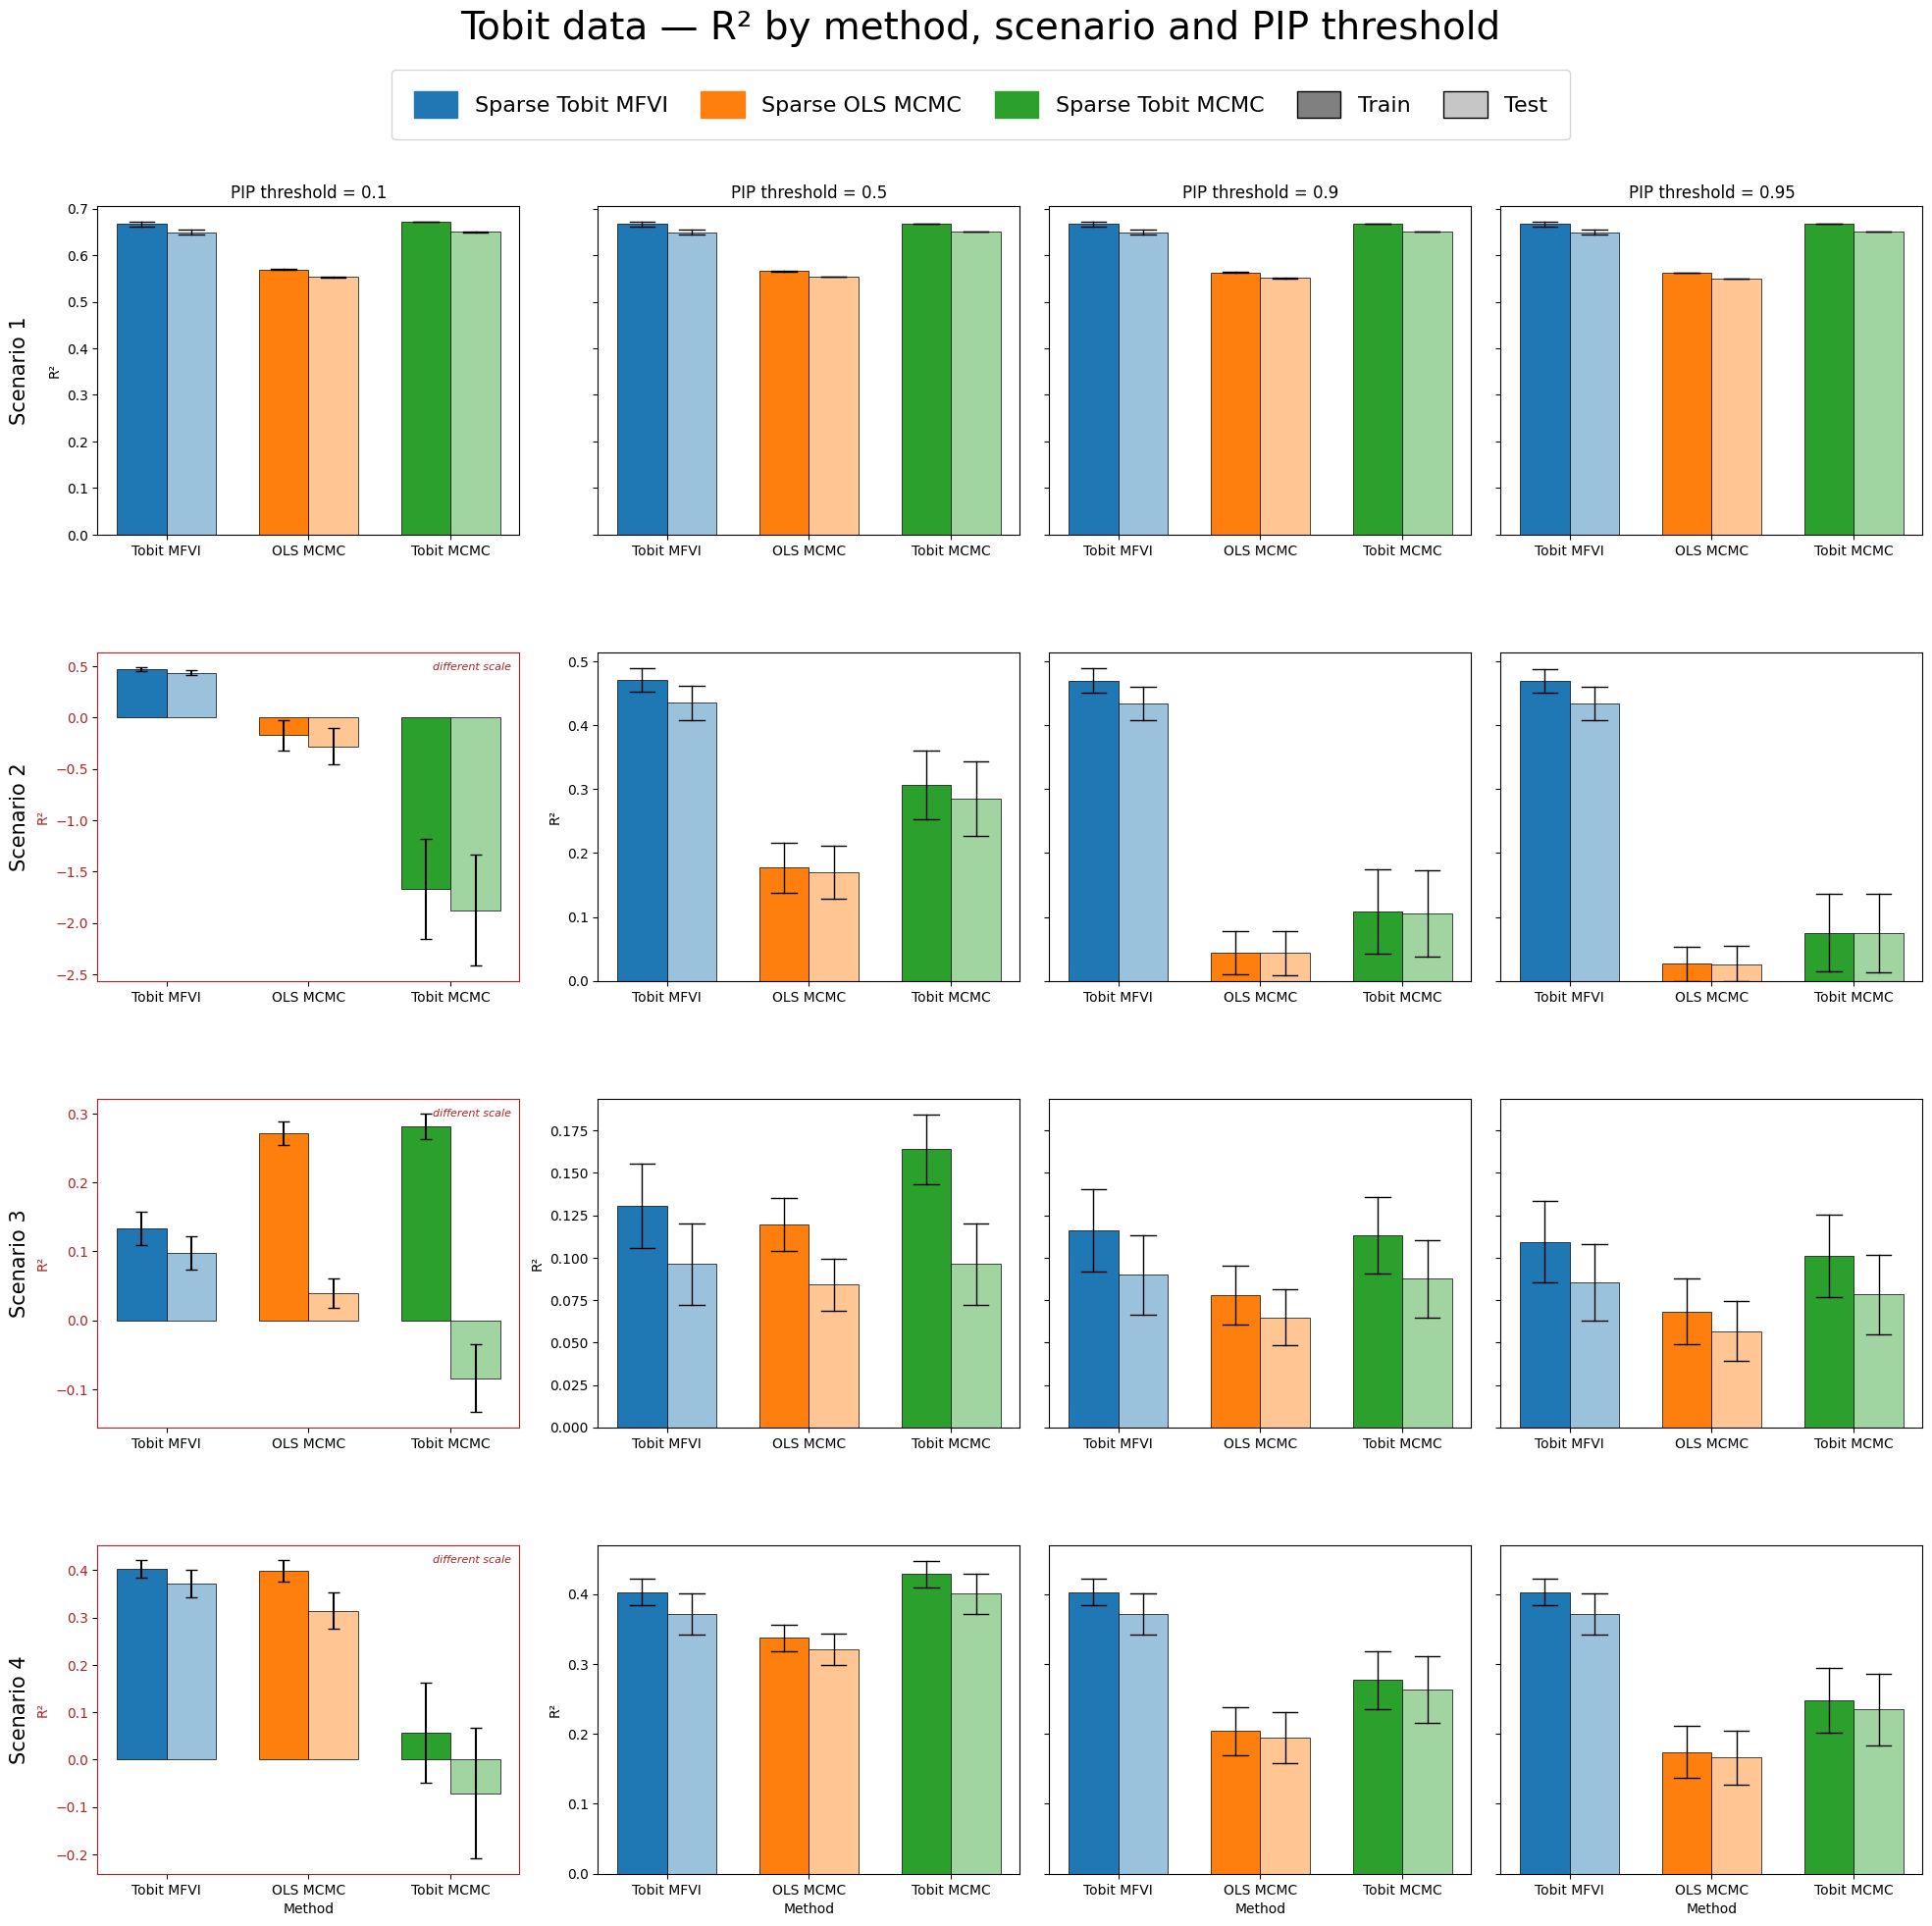

In [51]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgb

methods_order = ["mfvi", "ols", "gibbs"]
labels = {"mfvi": "Sparse Tobit MFVI", "ols": "Sparse OLS MCMC", "gibbs": "Sparse Tobit MCMC"}
short_labels = {m: lbl.replace("Sparse ", "") for m, lbl in labels.items()}
colors = {"mfvi": "tab:blue", "ols": "tab:orange", "gibbs": "tab:green"}

# A panel is "problematic" only if a MEAN (not just a whisker) is below 0.
PROBLEM_THRESHOLD = 0.0
PAD_FRAC = 0.05

# Manual layout parameters (figure-fraction units)
LEFT_MARGIN = 0.05
RIGHT_MARGIN = 0.02
TOP_MARGIN = 0.10
BOTTOM_MARGIN = 0.05
ROW_GAP = 0.06
COL_GAP_SMALL = 0.015
COL_GAP_LARGE_0_1 = 0.04


def lighten(color, amount=0.5):
    # Blend the color with white to produce a lighter shade
    r, g, b = to_rgb(color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)


def draw_bar_clipped_floor(ax, xpos, mean, std, width, color, y_floor):
    """Draw a normal bar + error whiskers, but clip the LOWER whisker at
    y_floor if it would otherwise go below the axis (no annotation needed —
    this only happens to whiskers, means stay >= y_floor by construction)."""
    ax.bar(xpos, mean, width, color=color, edgecolor="black", linewidth=0.5)
    err_top = mean + std
    err_bot = max(mean - std, y_floor)
    ax.plot([xpos, xpos], [err_bot, err_top], color="black", linewidth=1)
    cap_w = width * 0.25
    ax.plot([xpos - cap_w, xpos + cap_w], [err_top, err_top], color="black", linewidth=1)
    ax.plot([xpos - cap_w, xpos + cap_w], [err_bot, err_bot], color="black", linewidth=1)


# Get pip thresholds (assumed identical across scenarios)
pip_thresholds = stats["scenario_1"]["mfvi"][0]["pip_tr"].unique()[:-1]

n_panels = len(pip_thresholds)
n_scenarios = len(scenarios)
bar_width = 0.35
x = np.arange(len(methods_order))

# --- Step 1: precompute all bar values, flag panels as "problematic" only
# when a MEAN is below PROBLEM_THRESHOLD.
all_values = {}
problematic = {}

for scenario in scenarios:
    all_values[scenario] = {}
    problematic[scenario] = {}
    for pip_tr in pip_thresholds:
        means_train, stds_train = [], []
        means_test, stds_test = [], []
        for method in methods_order:
            dfs = stats[scenario][method]
            r2_train = [df.loc[df["pip_tr"] == pip_tr, "R2_train"].iloc[0] for df in dfs]
            r2_test = [df.loc[df["pip_tr"] == pip_tr, "R2_test"].iloc[0] for df in dfs]
            means_train.append(np.mean(r2_train))
            stds_train.append(np.std(r2_train))
            means_test.append(np.mean(r2_test))
            stds_test.append(np.std(r2_test))
        all_values[scenario][pip_tr] = {
            "means_train": means_train, "stds_train": stds_train,
            "means_test": means_test, "stds_test": stds_test,
        }
        panel_min_mean = min(means_train + means_test)
        problematic[scenario][pip_tr] = panel_min_mean < PROBLEM_THRESHOLD

# --- Step 2: compute a shared y-limit PER SCENARIO (row), using only the
# "normal" (non-problematic) panels of that row. Since all means in a
# normal row are >= 0, the lower limit is fixed at 0 (no floating bars) and
# whiskers dipping below 0 get clipped at draw time instead.
row_ylims = {}
for scenario in scenarios:
    highs = []
    for pip_tr in pip_thresholds:
        if problematic[scenario][pip_tr]:
            continue
        v = all_values[scenario][pip_tr]
        for mean_list, std_list in [(v["means_train"], v["stds_train"]),
                                     (v["means_test"], v["stds_test"])]:
            for m, s in zip(mean_list, std_list):
                highs.append(m + s)

    if highs:
        hi = max(highs)
        row_ylims[scenario] = (0.0, hi * (1 + PAD_FRAC))
    else:
        row_ylims[scenario] = None  # all panels in this row are problematic


# --- Step 3: custom axes positions, larger gap only between column 0 and 1.
def col_positions(n_cols):
    total_width = 1.0 - LEFT_MARGIN - RIGHT_MARGIN
    if n_cols == 1:
        gaps_sum = 0.0
    else:
        gaps_sum = COL_GAP_LARGE_0_1 + max(0, n_cols - 2) * COL_GAP_SMALL
    panel_w = (total_width - gaps_sum) / n_cols

    xs = []
    x0 = LEFT_MARGIN
    for c in range(n_cols):
        xs.append(x0)
        x0 += panel_w
        x0 += COL_GAP_LARGE_0_1 if c == 0 else COL_GAP_SMALL
    return xs, panel_w


def row_positions(n_rows):
    total_height = 1.0 - TOP_MARGIN - BOTTOM_MARGIN
    gaps_sum = max(0, n_rows - 1) * ROW_GAP
    panel_h = (total_height - gaps_sum) / n_rows

    ys = []
    y_top = 1.0 - TOP_MARGIN
    for r in range(n_rows):
        y0 = y_top - panel_h
        ys.append(y0)
        y_top = y0 - ROW_GAP
    return ys, panel_h


col_xs, panel_w = col_positions(n_panels)
row_ys, panel_h = row_positions(n_scenarios)

fig = plt.figure(figsize=(5 * n_panels, 5 * n_scenarios))
axes = [[fig.add_axes([col_xs[c], row_ys[r], panel_w, panel_h])
         for c in range(n_panels)] for r in range(n_scenarios)]

for row_idx, scenario in enumerate(scenarios):
    row_ylim = row_ylims[scenario]

    normal_cols = [c for c, pip_tr in enumerate(pip_thresholds) if not problematic[scenario][pip_tr]]
    first_normal_col = normal_cols[0] if normal_cols else None

    shared_ref_ax = None

    for col_idx, pip_tr in enumerate(pip_thresholds):
        ax = axes[row_idx][col_idx]
        v = all_values[scenario][pip_tr]
        is_problematic = problematic[scenario][pip_tr]

        train_colors = [colors[m] for m in methods_order]
        test_colors = [lighten(colors[m], amount=0.55) for m in methods_order]

        if is_problematic:
            # Problematic panels can genuinely have negative means, so draw
            # ordinary (unclipped) bars/whiskers here.
            ax.bar(x - bar_width / 2, v["means_train"], bar_width, yerr=v["stds_train"],
                   capsize=4, color=train_colors, edgecolor="black", linewidth=0.5)
            ax.bar(x + bar_width / 2, v["means_test"], bar_width, yerr=v["stds_test"],
                   capsize=4, color=test_colors, edgecolor="black", linewidth=0.5)

            p_lo = min([m - s for m, s in zip(v["means_train"], v["stds_train"])] +
                       [m - s for m, s in zip(v["means_test"], v["stds_test"])])
            p_hi = max([m + s for m, s in zip(v["means_train"], v["stds_train"])] +
                       [m + s for m, s in zip(v["means_test"], v["stds_test"])])
            p_span = p_hi - p_lo if p_hi > p_lo else 1.0
            ax.set_ylim(p_lo - PAD_FRAC * p_span, p_hi + PAD_FRAC * p_span)

            ax.tick_params(axis="y", labelcolor="firebrick")
            for spine in ax.spines.values():
                spine.set_edgecolor("firebrick")
            ax.text(0.98, 0.97, "different scale", transform=ax.transAxes,
                    ha="right", va="top", fontsize=8, color="firebrick", style="italic")
            ax.set_ylabel("R²", color="firebrick")
        else:
            y_floor = row_ylim[0]  # 0.0
            for i, method in enumerate(methods_order):
                draw_bar_clipped_floor(ax, x[i] - bar_width / 2, v["means_train"][i], v["stds_train"][i],
                                        bar_width, train_colors[i], y_floor)
                draw_bar_clipped_floor(ax, x[i] + bar_width / 2, v["means_test"][i], v["stds_test"][i],
                                        bar_width, test_colors[i], y_floor)

            ax.set_ylim(row_ylim)
            if shared_ref_ax is None:
                shared_ref_ax = ax
            else:
                ax.sharey(shared_ref_ax)
            if col_idx != first_normal_col:
                plt.setp(ax.get_yticklabels(), visible=False)

        ax.set_xticks(x)
        ax.set_xticklabels([short_labels[m] for m in methods_order])

        if row_idx == 0:
            ax.set_title(f"PIP threshold = {pip_tr}")

        if row_idx == n_scenarios - 1:
            ax.set_xlabel("Method")

        if col_idx == first_normal_col:
            ax.set_ylabel("R²")

    row_label = scenario.replace("_", " ").capitalize()
    anchor_ax = axes[row_idx][0]
    anchor_ax.annotate(
        row_label,
        xy=(0, 0.5), xytext=(-50, 0),
        xycoords="axes fraction", textcoords="offset points",
        size=15, ha="right", va="center", rotation=90
    )

# Single shared legend
method_handles = [plt.Rectangle((0, 0), 1, 1, color=colors[m]) for m in methods_order]
shade_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="gray", edgecolor="black"),
    plt.Rectangle((0, 0), 1, 1, facecolor=lighten("gray", 0.55), edgecolor="black"),
]
all_handles = method_handles + shade_handles
all_labels = [labels[m] for m in methods_order] + ["Train", "Test"]

fig.suptitle("Tobit data — R² by method, scenario and PIP threshold", y=1, fontsize=28)
fig.legend(all_handles, all_labels, loc="upper center", ncol=len(all_labels),
           bbox_to_anchor=(0.5, 0.975),
           fontsize=16, handlelength=2, handleheight=1.5,
           borderpad=1, labelspacing=1.2, columnspacing=1.5)

fig.savefig("viz/r2/r2_by_scenario_and_pip.png", dpi=300, bbox_inches="tight")
plt.show()

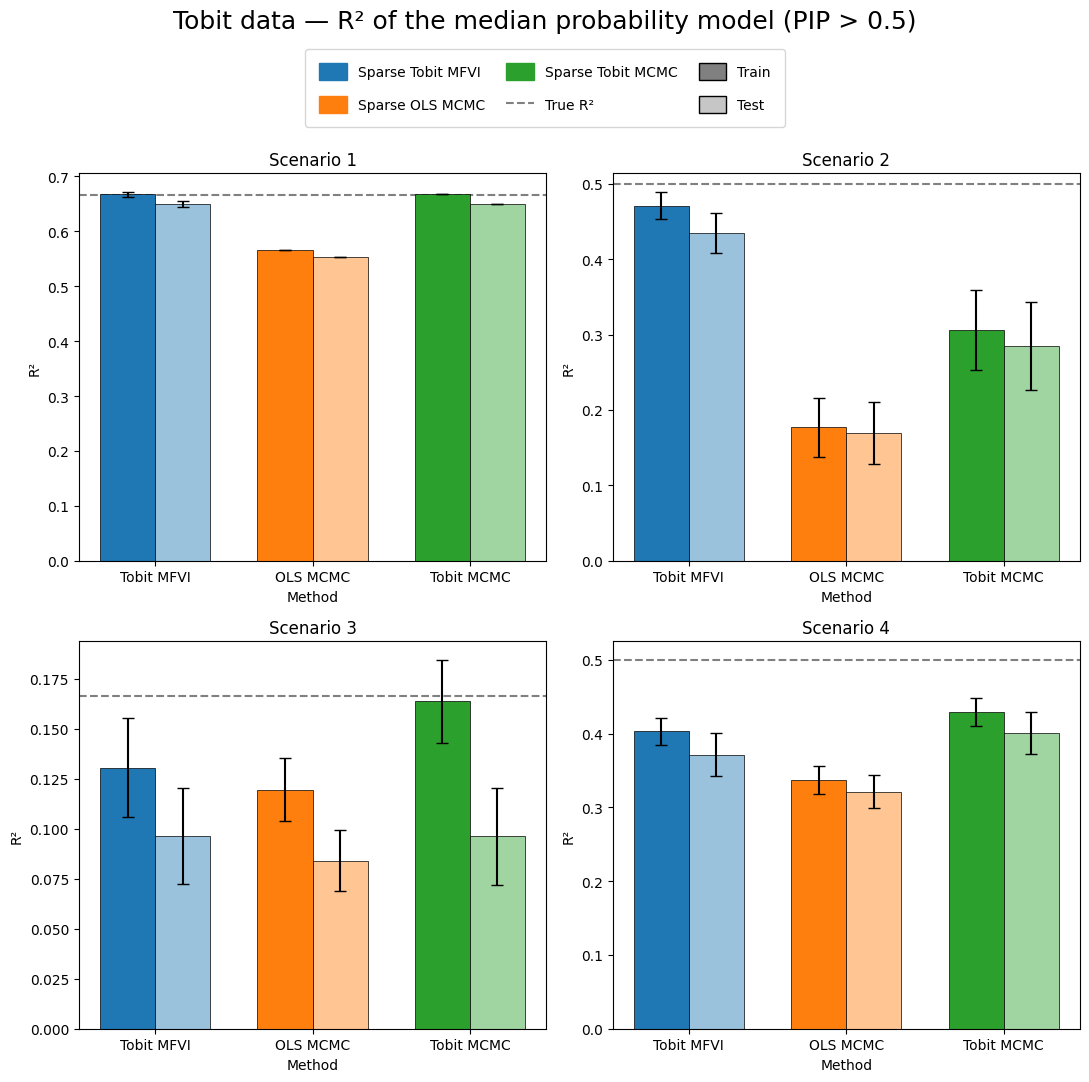

In [59]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgb

methods_order = ["mfvi", "ols", "gibbs"]
labels = {"mfvi": "Sparse Tobit MFVI", "ols": "Sparse OLS MCMC", "gibbs": "Sparse Tobit MCMC"}
short_labels = {m: lbl.replace("Sparse ", "") for m, lbl in labels.items()}
colors = {"mfvi": "tab:blue", "ols": "tab:orange", "gibbs": "tab:green"}

# Median Probability Model: PIP threshold = 0.5
MPM_PIP_TR = 0.5

# SNR per scenario, with total variance of y* fixed at 1:
# var(y*) = signal_var + noise_var = 1, SNR = signal_var / noise_var
# => signal_var = SNR / (1 + SNR) = ground-truth R^2
snr = {"scenario_1": 2, "scenario_2": 1, "scenario_3": 0.2, "scenario_4": 1}
ground_truth_r2 = {s: snr[s] / (1 + snr[s]) for s in snr}


def lighten(color, amount=0.5):
    # Blend the color with white to produce a lighter shade
    r, g, b = to_rgb(color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)


bar_width = 0.35
x = np.arange(len(methods_order))

fig, axes = plt.subplots(2, 2, figsize=(11, 11), sharey=False)
axes = axes.flatten()

for idx, scenario in enumerate(scenarios):
    ax = axes[idx]

    # Compute mean/std R2 at the MPM threshold, per method
    means_train, stds_train = [], []
    means_test, stds_test = [], []
    for method in methods_order:
        dfs = stats[scenario][method]
        r2_train = [df.loc[df["pip_tr"] == MPM_PIP_TR, "R2_train"].iloc[0] for df in dfs]
        r2_test = [df.loc[df["pip_tr"] == MPM_PIP_TR, "R2_test"].iloc[0] for df in dfs]
        means_train.append(np.mean(r2_train))
        stds_train.append(np.std(r2_train))
        means_test.append(np.mean(r2_test))
        stds_test.append(np.std(r2_test))

    train_colors = [colors[m] for m in methods_order]
    test_colors = [lighten(colors[m], amount=0.55) for m in methods_order]

    ax.bar(x - bar_width / 2, means_train, bar_width, yerr=stds_train,
           capsize=4, color=train_colors, edgecolor="black", linewidth=0.5)
    ax.bar(x + bar_width / 2, means_test, bar_width, yerr=stds_test,
           capsize=4, color=test_colors, edgecolor="black", linewidth=0.5)

    # Ground-truth R^2 line, drawn behind the bars
    ax.axhline(ground_truth_r2[scenario], color="gray", linestyle="--",
               linewidth=1.5, zorder=0, label="True R²")

    ax.set_xticks(x)
    ax.set_xticklabels([short_labels[m] for m in methods_order])
    ax.set_title(scenario.replace("_", " ").capitalize())
    ax.set_xlabel("Method")
    ax.set_ylabel("R²")

# Single shared legend: method colors (train) + train/test shade + ground truth line
method_handles = [plt.Rectangle((0, 0), 1, 1, color=colors[m]) for m in methods_order]
shade_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="gray", edgecolor="black"),
    plt.Rectangle((0, 0), 1, 1, facecolor=lighten("gray", 0.55), edgecolor="black"),
]
gt_handle = [plt.Line2D([0], [0], color="gray", linestyle="--", linewidth=1.5)]

all_handles = method_handles +gt_handle + shade_handles 
all_labels = [labels[m] for m in methods_order] + ["True R²", "Train", "Test"]

fig.suptitle("Tobit data — R² of the median probability model (PIP > 0.5)",
             y=0.98, x =0.5,fontsize=18)
fig.legend(all_handles, all_labels, loc="upper center", ncol=3,
           bbox_to_anchor=(0.5, 0.95),
           fontsize=10, handlelength=2, handleheight=1.5,
           borderpad=1, labelspacing=1.2, columnspacing=1.5)

plt.tight_layout(rect=[0, 0, 1, 0.90])
fig.savefig("viz/r2/r2_by_scenario_mpm.png", dpi=300, bbox_inches="tight")
plt.show()

In [202]:
import pandas as pd

pip_tr_target = 0.5
metrics = ["Precision", "Recall", "Accuracy", "MCC"]

summary_rows = []
for method in methods_order:
    dfs = stats[method]
    row = {"Method": labels[method]}
    for metric in metrics:
        values = [df.loc[df["pip_tr"] == pip_tr_target, metric].iloc[0] for df in dfs]
        row[f"{metric}_mean"] = np.mean(values)
        row[f"{metric}_std"] = np.std(values)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Method")

# Reorder columns so mean/std pairs sit together per metric
ordered_cols = [f"{m}_{stat}" for m in metrics for stat in ("mean", "std")]
summary_df = summary_df[ordered_cols]

summary_df.round(3)

,Precision_mean,Precision_std,Recall_mean,Recall_std,Accuracy_mean,Accuracy_std,MCC_mean,MCC_std
Method,,,,,,,,
MFVI,0.347,0.077,0.130,0.030,0.995,0.001,0.210,0.046
OLS,0.794,0.068,0.290,0.040,0.996,0.001,0.478,0.046
Gibbs,0.796,0.055,0.313,0.039,0.996,0.000,0.497,0.042


In [61]:
methods = ["mfvi", "ols", "gibbs"]

betas = {
    scenario: {
        method: [
            pd.read_csv(f"{folder}/{scenario}/{seed}/{method}_{seed}_beta.csv", index_col=0)
            for seed in subfolders[scenario]
        ]
        for method in methods
    }
    for scenario in scenarios
}

display(betas["scenario_1"]["mfvi"][0].head())

,pip,true_sig,true_size,beta_mean,beta_std,beta_hdi_low,beta_hdi_high
var_idx,,,,,,,
0,1.000000e-10,False,0.0,-8.733595e-11,0.195434,-0.383044,0.383044
1,1.000000e-10,False,-0.0,-1.525013e-11,0.195434,-0.383044,0.383044
2,1.000000e-10,False,-0.0,-1.327347e-10,0.195434,-0.383044,0.383044
3,1.000000e-10,False,-0.0,-3.604332e-10,0.195434,-0.383044,0.383044
4,1.000000e-10,False,0.0,1.419429e-10,0.195434,-0.383044,0.383044


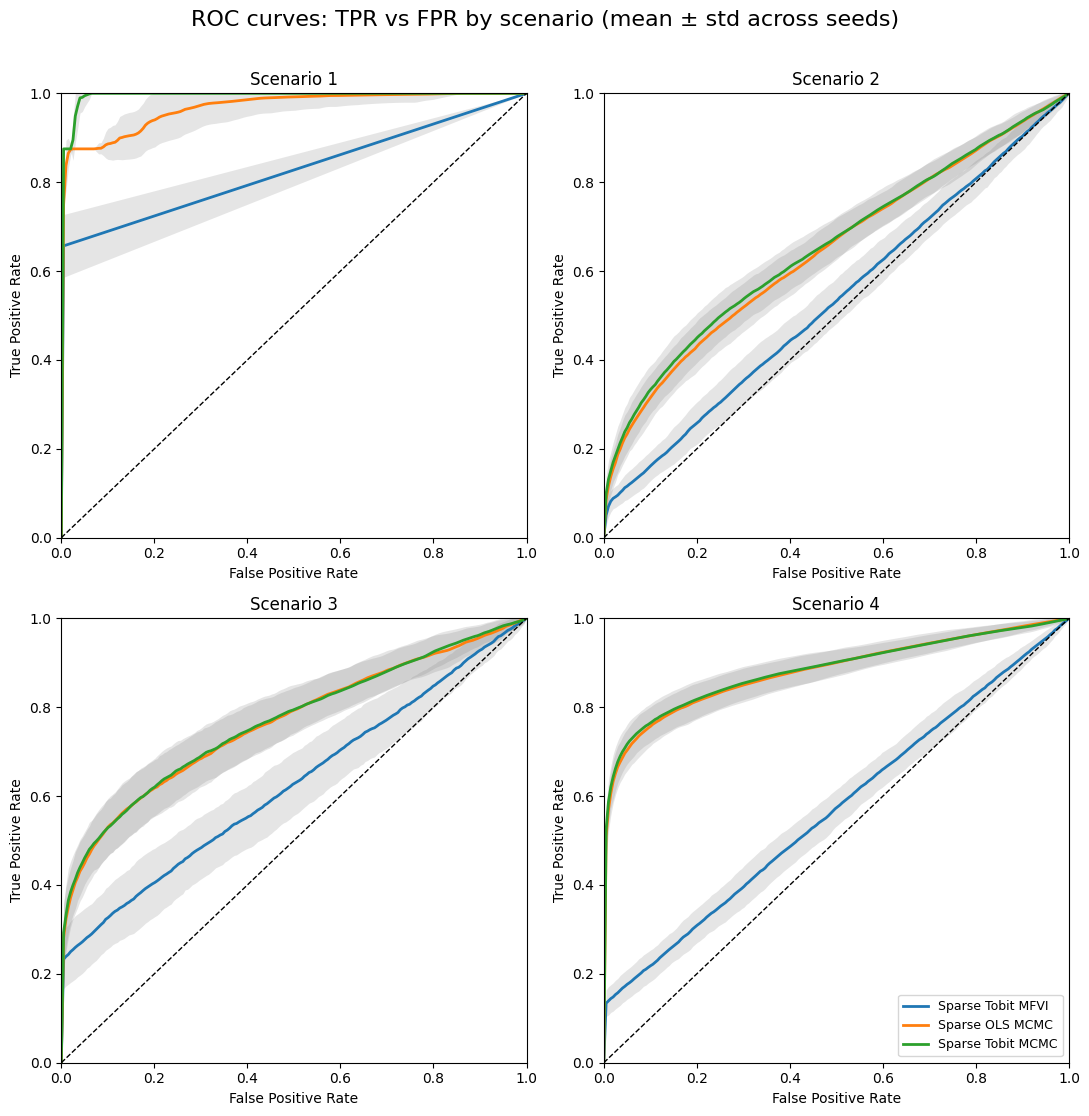

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

methods_order = ["mfvi", "ols", "gibbs"]
labels = {"mfvi": "Sparse Tobit MFVI", "ols": "Sparse OLS MCMC", "gibbs": "Sparse Tobit MCMC"}
colors = {"mfvi": "tab:blue", "ols": "tab:orange", "gibbs": "tab:green"}

# Common FPR grid for interpolation across seeds
fpr_grid = np.linspace(0, 1, 200)

fig, axes = plt.subplots(2, 2, figsize=(11, 11))
axes = axes.flatten()

for idx, scenario in enumerate(scenarios):
    ax = axes[idx]

    for method in methods_order:
        tpr_interp_list = []
        for df in betas[scenario][method]:
            y_true = df["true_sig"].astype(int).values
            y_score = df["pip"].values
            fpr, tpr, _ = roc_curve(y_true, y_score)
            # Interpolate this seed's ROC curve onto the common fpr grid
            tpr_interp = np.interp(fpr_grid, fpr, tpr)
            tpr_interp[0] = 0.0  # anchor curve at origin
            tpr_interp_list.append(tpr_interp)

        tpr_mean = np.mean(tpr_interp_list, axis=0)
        tpr_std = np.std(tpr_interp_list, axis=0)

        # Shaded +- std band in gray
        ax.fill_between(
            fpr_grid,
            np.clip(tpr_mean - tpr_std, 0, 1),
            np.clip(tpr_mean + tpr_std, 0, 1),
            color="gray",
            alpha=0.2,
            linewidth=0,
        )
        # Mean ROC curve in the method's established color
        ax.plot(fpr_grid, tpr_mean, color=colors[method], label=labels[method], linewidth=2)

    ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
    ax.set_title(scenario.replace("_", " ").capitalize())
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Legend only on the bottom-right panel (index 3 = row 1, col 1), lower right corner
    if idx == 3:
        ax.legend(loc="lower right", fontsize=9)

fig.suptitle("ROC curves: TPR vs FPR by scenario (mean ± std across seeds)",
             y=1.01, fontsize=16)

plt.tight_layout()
fig.savefig("viz/roc.png", dpi=300, bbox_inches="tight")
plt.show()

In [66]:
methods_order = ["mfvi", "ols", "gibbs"]
labels = {"mfvi": "Sparse Tobit MFVI", "ols": "Sparse OLS MCMC", "gibbs": "Sparse Tobit MCMC"}

time = {
    scenario: {
        method: [
            pd.read_csv(f"{folder}/{scenario}/{seed}/{method}_{seed}_time.csv", index_col=0)
            for seed in subfolders[scenario]
        ]
        for method in methods_order
    }
    for scenario in scenarios
}

# Columns to summarize (adjust if some methods lack certain columns, e.g. n_iters/converged)
time_metrics = ["total_fit_time", "n_iters"]

summary_rows = []
for scenario in scenarios:
    for method in methods_order:
        dfs = time[scenario][method]
        row = {"Scenario": scenario.replace("_", " ").capitalize(), "Method": labels[method]}
        for metric in time_metrics:
            if metric not in dfs[0].columns:
                continue
            values = [df[metric].iloc[0] for df in dfs]
            row[f"{metric}_mean"] = np.mean(values)
            row[f"{metric}_std"] = np.std(values)
        summary_rows.append(row)

time_summary_df = pd.DataFrame(summary_rows).set_index(["Scenario", "Method"])
time_summary_df.round(3)

total_fit_time_mean  total_fit_time_std  \
Scenario   Method                                                       
Scenario 1 Sparse Tobit MFVI                0.266               0.034   
           Sparse OLS MCMC                  8.791               0.814   
           Sparse Tobit MCMC               12.186               1.172   
Scenario 2 Sparse Tobit MFVI                3.626               0.656   
           Sparse OLS MCMC                 96.834              24.365   
           Sparse Tobit MCMC              107.573              27.707   
Scenario 3 Sparse Tobit MFVI                7.017               3.207   
           Sparse OLS MCMC                 83.781              10.879   
           Sparse Tobit MCMC               92.133              11.943   
Scenario 4 Sparse Tobit MFVI              211.939              61.950   
           Sparse OLS MCMC              10186.878            4321.089   
           Sparse Tobit MCMC            10571.154            4482.410   

                              n_iters_mean  n_iters_std  
Scenario   Method                                        
Scenario 1 Sparse Tobit MFVI         29.02        2.764  
           Sparse OLS MCMC             NaN          NaN  
           Sparse Tobit MCMC           NaN          NaN  
Scenario 2 Sparse Tobit MFVI         15.02        1.990  
           Sparse OLS MCMC             NaN          NaN  
           Sparse Tobit MCMC           NaN          NaN  
Scenario 3 Sparse Tobit MFVI         29.40       12.681  
           Sparse OLS MCMC             NaN          NaN  
           Sparse Tobit MCMC           NaN          NaN  
Scenario 4 Sparse Tobit MFVI         20.02        0.244  
           Sparse OLS MCMC             NaN          NaN  
           Sparse Tobit MCMC           NaN          NaN

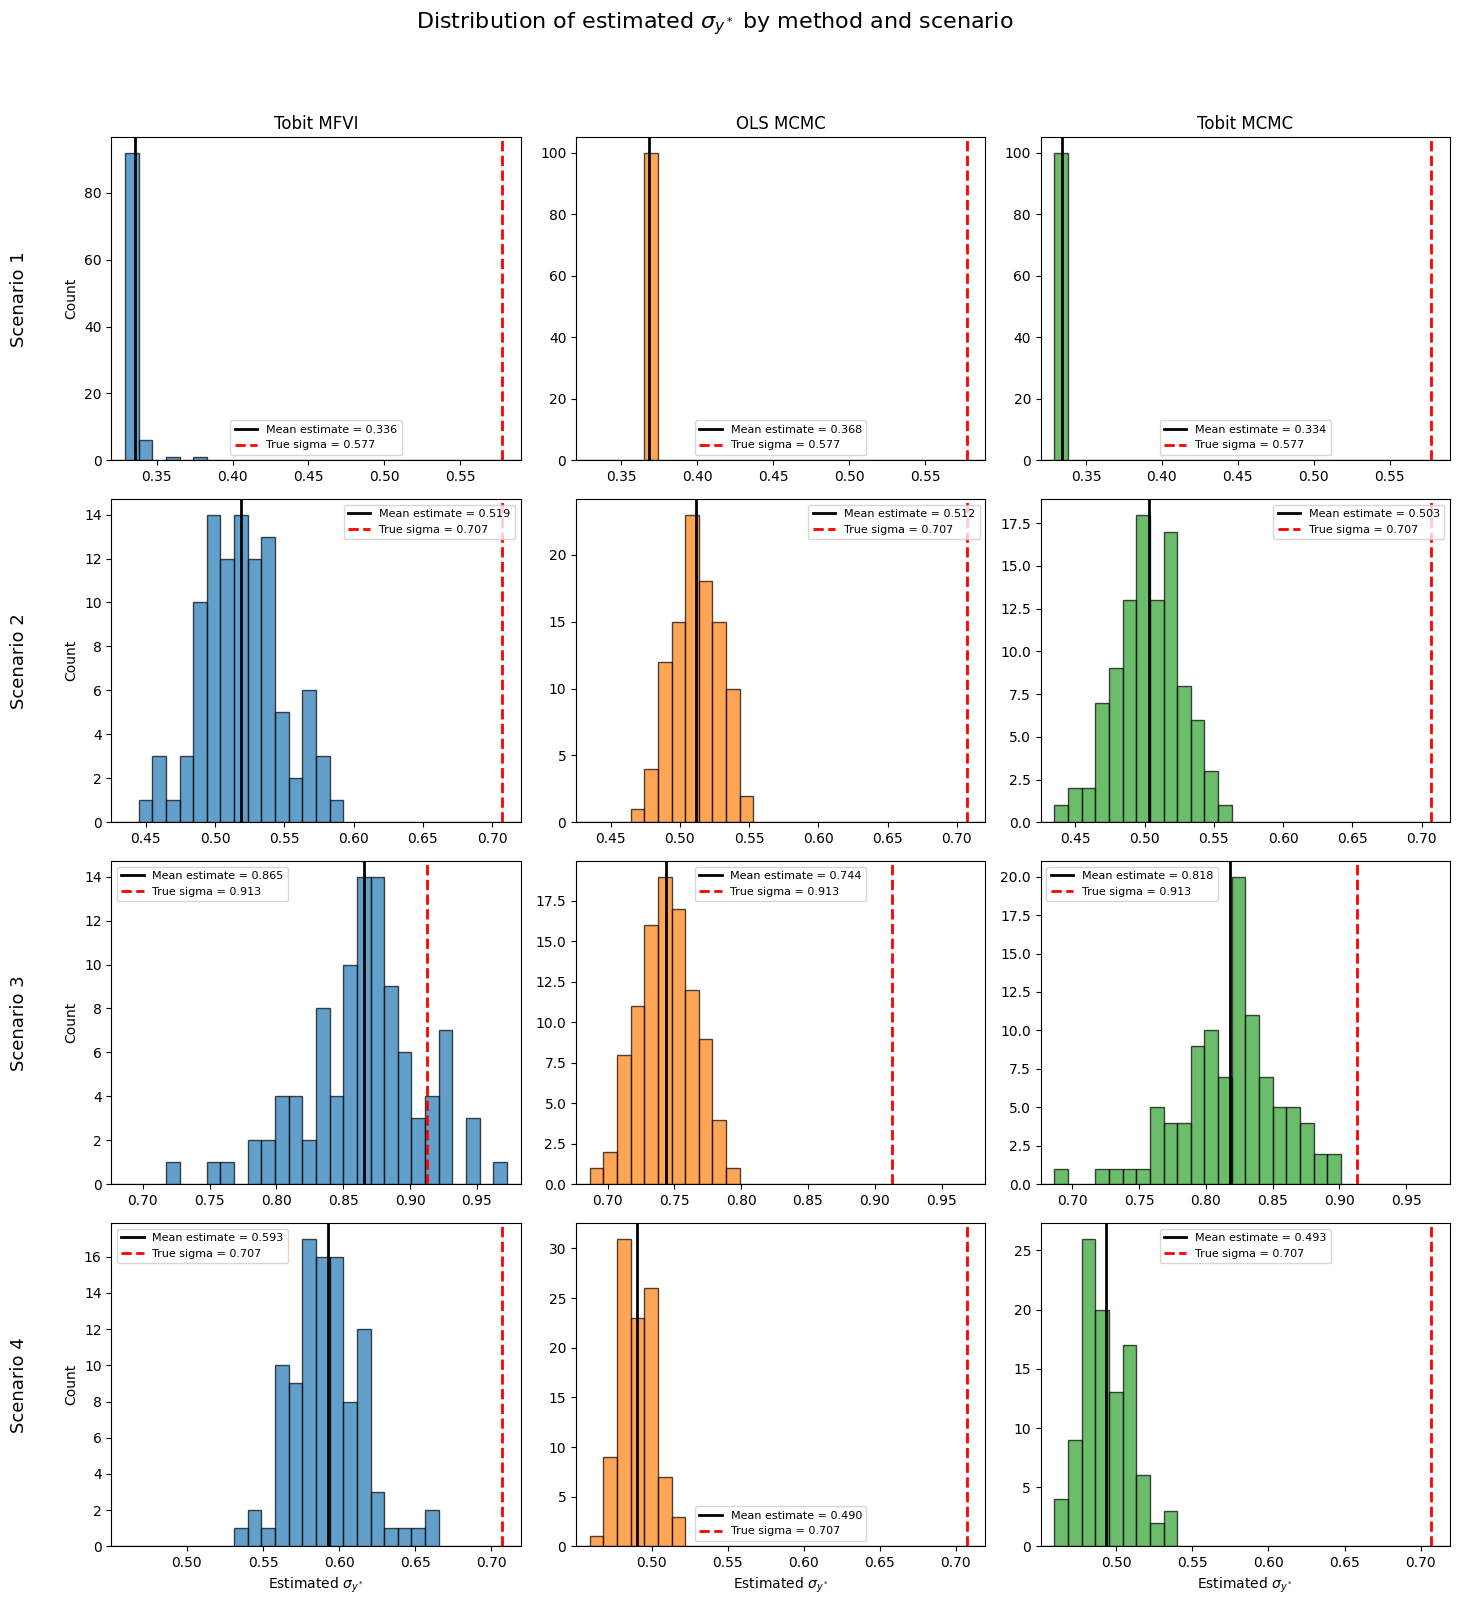

In [78]:
import matplotlib.pyplot as plt
import numpy as np

sigmas = {
    scenario: {
        method: [
            pd.read_csv(f"{folder}/{scenario}/{seed}/{method}_{seed}_sigma.csv", index_col=0)
            for seed in subfolders[scenario]
        ]
        for method in methods
    }
    for scenario in scenarios
}

methods_order = ["mfvi", "ols", "gibbs"]
labels = {"mfvi": "Sparse Tobit MFVI", "ols": "Sparse OLS MCMC", "gibbs": "Sparse Tobit MCMC"}
short_labels = {m: lbl.replace("Sparse ", "") for m, lbl in labels.items()}
colors = {"mfvi": "tab:blue", "ols": "tab:orange", "gibbs": "tab:green"}

N_BINS = 30  # number of histogram bins, spaced evenly across the shared x-axis range

n_scenarios = len(scenarios)
n_methods = len(methods_order)

fig, axes = plt.subplots(n_scenarios, n_methods, figsize=(5 * n_methods, 4 * n_scenarios), sharex=False)

for row_idx, scenario in enumerate(scenarios):
    # --- First pass: compute data and the shared x-range for this row (scenario)
    row_data = {}
    row_lo, row_hi = np.inf, -np.inf

    for method in methods_order:
        dfs = sigmas[scenario][method]
        est_means = np.array([df.loc["sigma", "mean"] for df in dfs])
        true_val = dfs[0].loc["sigma", "true_value"]
        row_data[method] = {"est_means": est_means, "true_val": true_val}

        row_lo = min(row_lo, est_means.min(), true_val)
        row_hi = max(row_hi, est_means.max(), true_val)

    pad = 0.05 * (row_hi - row_lo) if row_hi > row_lo else 0.1
    row_xlim = (row_lo - pad, row_hi + pad)
    # Bin edges spaced evenly across the axis range (not across the data range)
    bin_edges = np.linspace(row_xlim[0], row_xlim[1], N_BINS + 1)

    # --- Second pass: plot, using the shared x-range and bin edges for this row
    for col_idx, method in enumerate(methods_order):
        ax = axes[row_idx][col_idx]
        d = row_data[method]
        est_means, true_val = d["est_means"], d["true_val"]

        ax.hist(
            est_means,
            bins=bin_edges,
            color=colors[method],
            alpha=0.7,
            edgecolor="black",
        )

        ax.axvline(
            est_means.mean(),
            color="black",
            linestyle="-",
            linewidth=2,
            label=f"Mean estimate = {est_means.mean():.3f}",
        )
        ax.axvline(
            true_val,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"True sigma = {true_val:.3f}",
        )

        ax.set_xlim(row_xlim)

        if row_idx == 0:
            ax.set_title(short_labels[method])

        if row_idx == n_scenarios - 1:
            ax.set_xlabel(r"Estimated $\sigma_{y^*}$")

        if col_idx == 0:
            ax.set_ylabel("Count")

        ax.legend(loc="best", fontsize=8)

    row_label = scenario.replace("_", " ").capitalize()
    axes[row_idx][0].annotate(
        row_label,
        xy=(0, 0.5), xytext=(-60, 0),
        xycoords="axes fraction", textcoords="offset points",
        size=13, ha="right", va="center", rotation=90
    )

fig.suptitle(r"Distribution of estimated $\sigma_{y^*}$ by method and scenario", y=1.0, fontsize=16)
plt.tight_layout(rect=[0.02, 0, 1, 0.97])
fig.savefig("viz/sigma/distr.png", dpi=300, bbox_inches="tight")
plt.show()

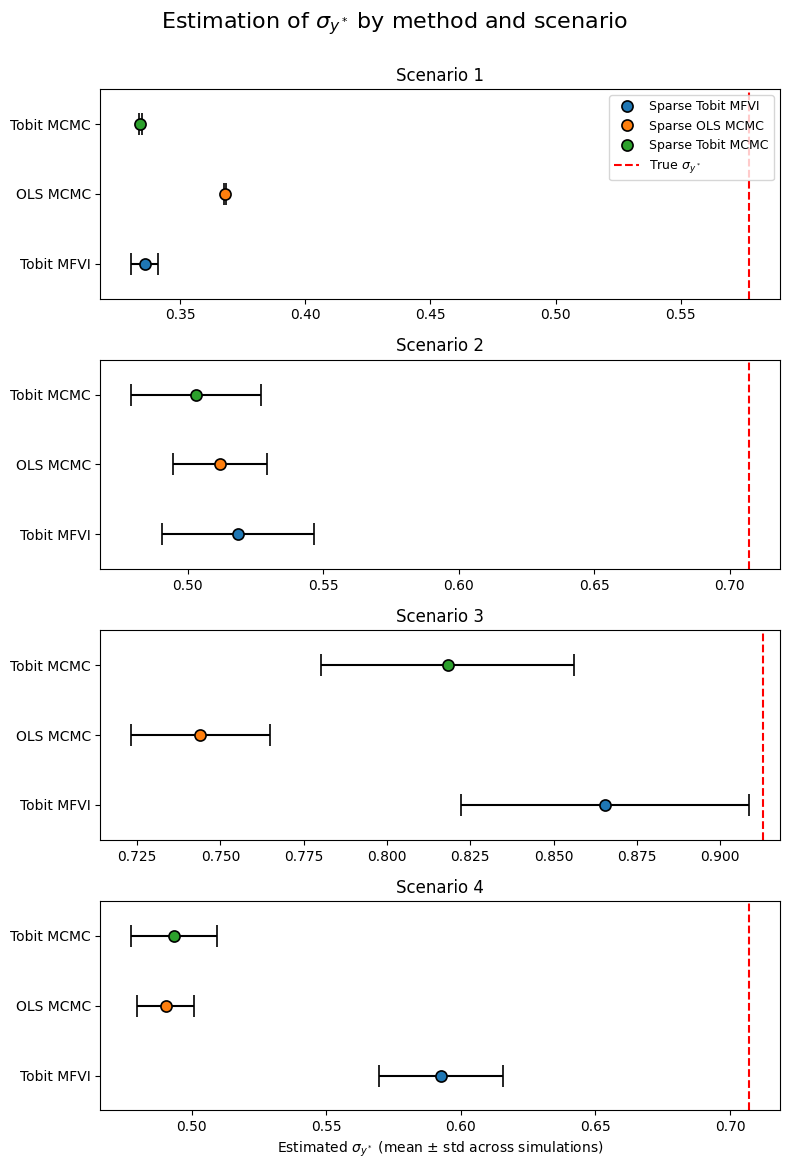

In [73]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

sigmas = {
    scenario: {
        method: [
            pd.read_csv(f"{folder}/{scenario}/{seed}/{method}_{seed}_sigma.csv", index_col=0)
            for seed in subfolders[scenario]
        ]
        for method in methods
    }
    for scenario in scenarios
}

methods_order = ["mfvi", "ols", "gibbs"]
labels = {"mfvi": "Sparse Tobit MFVI", "ols": "Sparse OLS MCMC", "gibbs": "Sparse Tobit MCMC"}
short_labels = {m: lbl.replace("Sparse ", "") for m, lbl in labels.items()}
colors = {"mfvi": "tab:blue", "ols": "tab:orange", "gibbs": "tab:green"}

y_positions = np.arange(len(methods_order))

# --- Precompute mean/std across seeds and true value, per scenario.
scenario_data = {}

for scenario in scenarios:
    true_val = sigmas[scenario][methods_order[0]][0].loc["sigma", "true_value"]
    means, stds = [], []
    for method in methods_order:
        dfs = sigmas[scenario][method]
        est_means = np.array([df.loc["sigma", "mean"] for df in dfs])
        means.append(est_means.mean())
        stds.append(est_means.std(ddof=1))

    scenario_data[scenario] = {"true_val": true_val, "means": means, "stds": stds}

fig, axes = plt.subplots(len(scenarios), 1, figsize=(8, 3 * len(scenarios)), sharex=False)

for idx, scenario in enumerate(scenarios):
    ax = axes[idx]
    d = scenario_data[scenario]

    for y, method in zip(y_positions, methods_order):
        ax.errorbar(
            d["means"][methods_order.index(method)], y,
            xerr=d["stds"][methods_order.index(method)],
            fmt="o",
            markersize=8,
            markerfacecolor=colors[method],
            markeredgecolor="black",
            markeredgewidth=1.2,
            ecolor="black",
            elinewidth=1.5,
            capsize=8,
            capthick=1.5,
        )

    # Reference line for the true sigma value (specific to this scenario)
    ax.axvline(d["true_val"], color="red", linestyle="--", linewidth=1.5)

    ax.set_yticks(y_positions)
    ax.set_yticklabels([short_labels[m] for m in methods_order])
    ax.set_ylim(-0.5, len(methods_order) - 0.5)

    ax.set_title(scenario.replace("_", " ").capitalize())

    if idx == len(scenarios) - 1:
        ax.set_xlabel(r"Estimated $\sigma_{y^*}$ (mean ± std across simulations)")

    if idx == 0:
        method_handles = [
            Line2D(
                [0], [0],
                marker="o", linestyle="",
                markerfacecolor=colors[m], markeredgecolor="black", markeredgewidth=1.2,
                markersize=8, label=labels[m],
            )
            for m in methods_order
        ]
        true_handle = Line2D(
            [0], [0], color="red", linestyle="--", linewidth=1.5,
            label=r"True $\sigma_{y^*}$",
        )
        ax.legend(handles=method_handles + [true_handle], loc="upper right", fontsize=9)

fig.suptitle(r"Estimation of $\sigma_{y^*}$ by method and scenario", y=0.97, fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig("viz/sigma/mean_and_std_across_scenarios1.png", dpi=300, bbox_inches="tight")
plt.show()

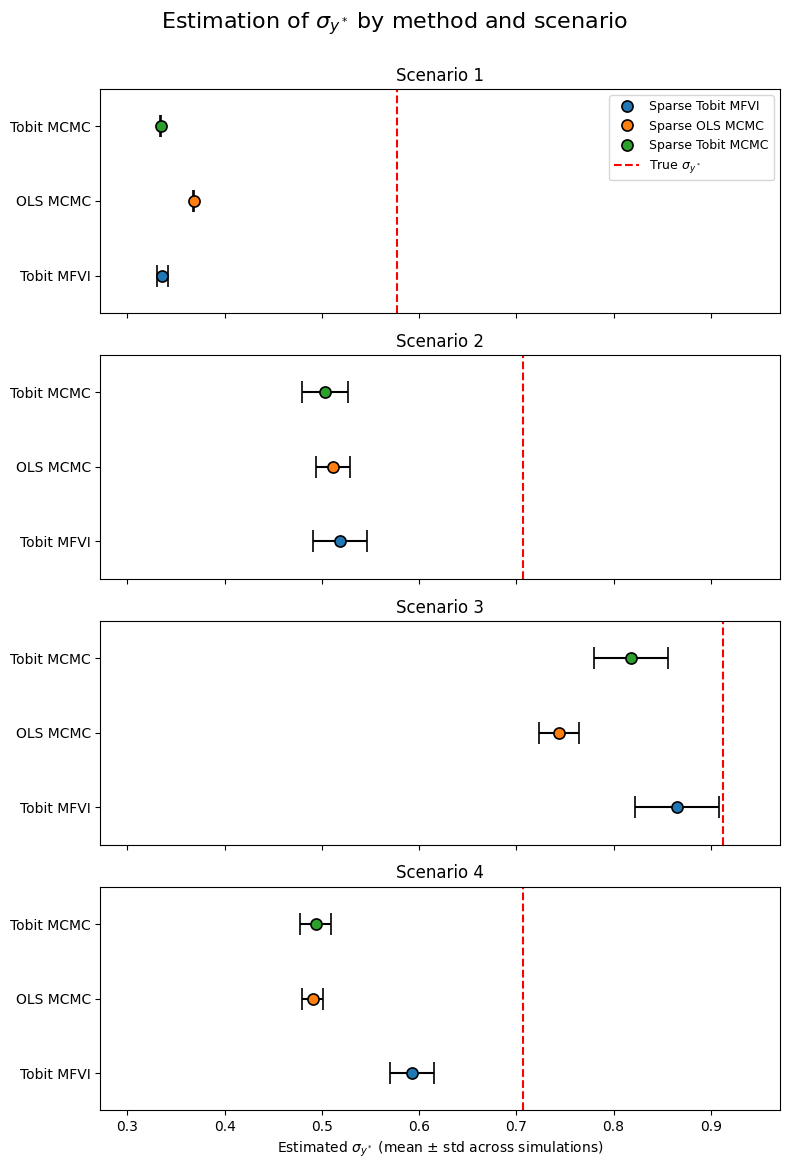

In [72]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

sigmas = {
    scenario: {
        method: [
            pd.read_csv(f"{folder}/{scenario}/{seed}/{method}_{seed}_sigma.csv", index_col=0)
            for seed in subfolders[scenario]
        ]
        for method in methods
    }
    for scenario in scenarios
}

methods_order = ["mfvi", "ols", "gibbs"]
labels = {"mfvi": "Sparse Tobit MFVI", "ols": "Sparse OLS MCMC", "gibbs": "Sparse Tobit MCMC"}
short_labels = {m: lbl.replace("Sparse ", "") for m, lbl in labels.items()}
colors = {"mfvi": "tab:blue", "ols": "tab:orange", "gibbs": "tab:green"}

y_positions = np.arange(len(methods_order))

# --- Precompute mean/std across seeds and true value, per scenario, and
# track the global x-range so all panels can share the same x-axis scale.
scenario_data = {}
global_lo, global_hi = np.inf, -np.inf

for scenario in scenarios:
    true_val = sigmas[scenario][methods_order[0]][0].loc["sigma", "true_value"]
    means, stds = [], []
    for method in methods_order:
        dfs = sigmas[scenario][method]
        est_means = np.array([df.loc["sigma", "mean"] for df in dfs])
        means.append(est_means.mean())
        stds.append(est_means.std(ddof=1))

    scenario_data[scenario] = {"true_val": true_val, "means": means, "stds": stds}

    lo = min(min(np.array(means) - np.array(stds)), true_val)
    hi = max(max(np.array(means) + np.array(stds)), true_val)
    global_lo, global_hi = min(global_lo, lo), max(global_hi, hi)

pad = 0.1 * (global_hi - global_lo)
shared_xlim = (global_lo - pad, global_hi + pad)

fig, axes = plt.subplots(len(scenarios), 1, figsize=(8, 3 * len(scenarios)), sharex=True)

for idx, scenario in enumerate(scenarios):
    ax = axes[idx]
    d = scenario_data[scenario]

    for y, method in zip(y_positions, methods_order):
        ax.errorbar(
            d["means"][methods_order.index(method)], y,
            xerr=d["stds"][methods_order.index(method)],
            fmt="o",
            markersize=8,
            markerfacecolor=colors[method],
            markeredgecolor="black",
            markeredgewidth=1.2,
            ecolor="black",
            elinewidth=1.5,
            capsize=8,
            capthick=1.5,
        )

    # Reference line for the true sigma value (specific to this scenario)
    ax.axvline(d["true_val"], color="red", linestyle="--", linewidth=1.5)

    ax.set_yticks(y_positions)
    ax.set_yticklabels([short_labels[m] for m in methods_order])
    ax.set_ylim(-0.5, len(methods_order) - 0.5)
    ax.set_xlim(shared_xlim)

    ax.set_title(scenario.replace("_", " ").capitalize())

    if idx == len(scenarios) - 1:
        ax.set_xlabel(r"Estimated $\sigma_{y^*}$ (mean ± std across simulations)")

    if idx == 0:
        method_handles = [
            Line2D(
                [0], [0],
                marker="o", linestyle="",
                markerfacecolor=colors[m], markeredgecolor="black", markeredgewidth=1.2,
                markersize=8, label=labels[m],
            )
            for m in methods_order
        ]
        true_handle = Line2D(
            [0], [0], color="red", linestyle="--", linewidth=1.5,
            label=r"True $\sigma_{y^*}$",
        )
        ax.legend(handles=method_handles + [true_handle], loc="upper right", fontsize=9)

fig.suptitle(r"Estimation of $\sigma_{y^*}$ by method and scenario", y=0.97, fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig("viz/sigma/mean_and_std_across_scenarios2.png", dpi=300, bbox_inches="tight")
plt.show()

In [81]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

methods_order = ["mfvi", "gibbs"]
labels = {"mfvi": "Sparse Tobit MFVI", "gibbs": "Sparse Tobit MCMC"}
colors = {"mfvi": "tab:blue", "gibbs": "tab:green"}

estimate_col = {"mfvi": "beta_mean", "gibbs": "beta_marg_mean"}
true_col = "true_size"

folder = "simulations"
multipliers = [1, 2, 4, 8]
# Folder name pattern per multiplier: 1x uses the base "scenario_x" folder,
# others use the "{mult}n_scenario_x" prefix.
def scenario_folder(scenario, mult):
    return scenario if mult == 1 else f"{mult}n_{scenario}"

# --- Step 1: discover subfolders (seeds) for every scenario x multiplier
subfolders_n = {
    scenario: {
        mult: [
            f.name for f in os.scandir(f"{folder}/{scenario_folder(scenario, mult)}")
            if f.is_dir() and f.name != ".ipynb_checkpoints"
        ]
        for mult in multipliers
    }
    for scenario in scenarios
}

print("Number of available simulations per scenario and sample-size multiplier:")
for scenario in scenarios:
    for mult in multipliers:
        print(f"{scenario}, {mult}x: {len(subfolders_n[scenario][mult])}")

# --- Step 2: load beta files for every scenario x multiplier x method
betas_n = {
    scenario: {
        mult: {
            method: [
                pd.read_csv(
                    f"{folder}/{scenario_folder(scenario, mult)}/{seed}/{method}_{seed}_beta.csv",
                    index_col=0,
                )
                for seed in subfolders_n[scenario][mult]
            ]
            for method in methods_order
        }
        for mult in multipliers
    }
    for scenario in scenarios
}

# --- Step 3: compute RMSE (per seed) of the estimated coefficient,
# restricted to truly non-zero coefficients (true_size != 0).
rmse_n = {
    scenario: {
        mult: {
            method: np.array([
                np.sqrt(np.mean(
                    (df.loc[df[true_col] != 0, estimate_col[method]]
                     - df.loc[df[true_col] != 0, true_col]) ** 2
                ))
                for df in betas_n[scenario][mult][method]
            ])
            for method in methods_order
        }
        for mult in multipliers
    }
    for scenario in scenarios
}

# --- Step 4: plot — 2x2 grid (one panel per scenario), boxplots grouped by
# sample-size multiplier on the x-axis, one box per method within each group.
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

box_width = 0.35
positions_base = np.arange(len(multipliers))

for idx, scenario in enumerate(scenarios):
    ax = axes[idx]

    for i, method in enumerate(methods_order):
        offset = (i - (len(methods_order) - 1) / 2) * box_width
        data = [rmse_n[scenario][mult][method] for mult in multipliers]
        positions = positions_base + offset

        bp = ax.boxplot(
            data, positions=positions, widths=box_width * 0.9,
            patch_artist=True, showfliers=False,
        )
        for patch in bp["boxes"]:
            patch.set_facecolor(colors[method])
            patch.set_alpha(0.7)
        for element in ["whiskers", "caps", "medians"]:
            for line in bp[element]:
                line.set_color("black")

    ax.set_xticks(positions_base)
    ax.set_xticklabels([f"{m}x" for m in multipliers])
    ax.set_title(scenario.replace("_", " ").capitalize())
    ax.set_xlabel("Sample size")
    ax.set_ylabel(r"RMSE of $\hat{\beta}$ (true nonzero coefficients)")

# Single shared legend
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=colors[m], alpha=0.7, edgecolor="black")
    for m in methods_order
]
fig.legend(legend_handles, [labels[m] for m in methods_order],
           loc="upper center", ncol=len(methods_order), bbox_to_anchor=(0.5, 0.98))

fig.suptitle(r"RMSE of $\hat{\beta}$ for truly significant predictors vs. sample size",
             y=1.03, fontsize=15)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'simulations/2n_scenario_4'

Number of available simulations per scenario and sample-size multiplier:
scenario_1, 1x: 100
scenario_1, 2x: 100
scenario_1, 4x: 100
scenario_1, 8x: 100
scenario_2, 1x: 100
scenario_2, 2x: 100
scenario_2, 4x: 100
scenario_2, 8x: 100
scenario_3, 1x: 100
scenario_3, 2x: 100
scenario_3, 4x: 100
scenario_3, 8x: 100


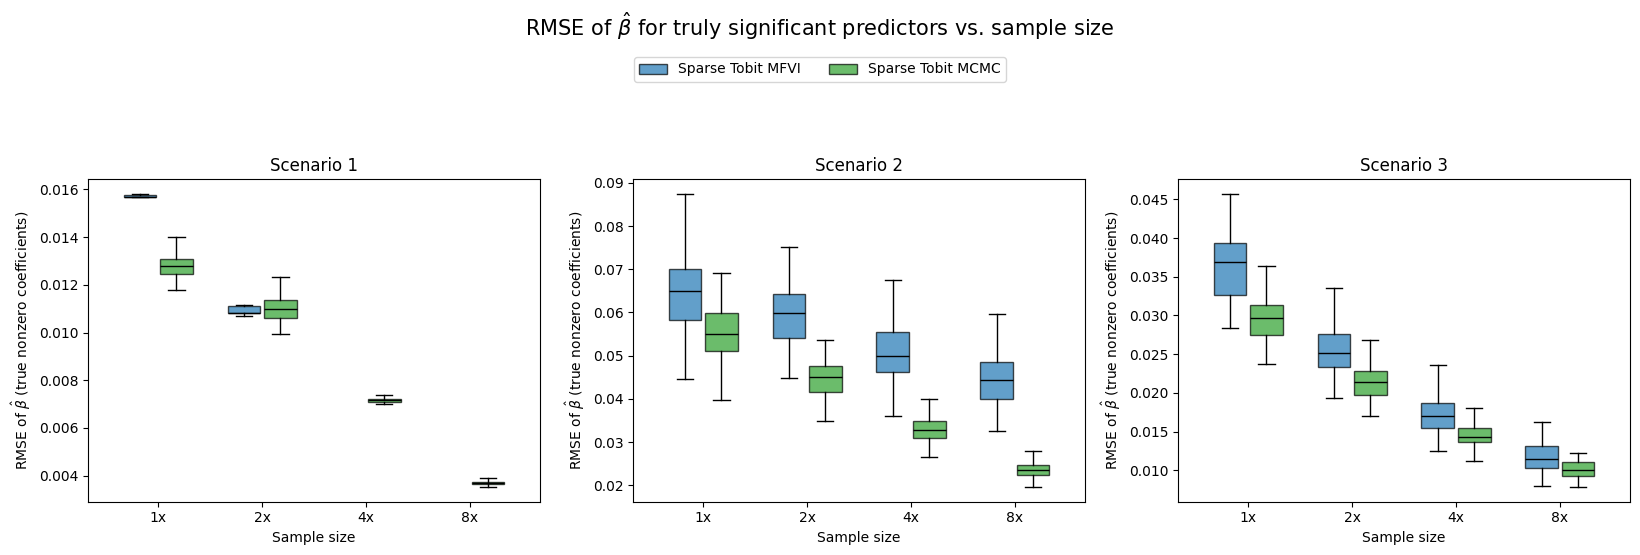

In [82]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

methods_order = ["mfvi", "gibbs"]
labels = {"mfvi": "Sparse Tobit MFVI", "gibbs": "Sparse Tobit MCMC"}
colors = {"mfvi": "tab:blue", "gibbs": "tab:green"}

estimate_col = {"mfvi": "beta_mean", "gibbs": "beta_marg_mean"}
true_col = "true_size"

folder = "simulations"
multipliers = [1, 2, 4, 8]

# Scenario 4 is excluded from this sample-size sweep (no data available)
sweep_scenarios = [s for s in scenarios if s != "scenario_4"]

# Folder name pattern per multiplier: 1x uses the base "scenario_x" folder,
# others use the "{mult}n_scenario_x" prefix.
def scenario_folder(scenario, mult):
    return scenario if mult == 1 else f"{mult}n_{scenario}"

# --- Step 1: discover subfolders (seeds) for every scenario x multiplier
subfolders_n = {
    scenario: {
        mult: [
            f.name for f in os.scandir(f"{folder}/{scenario_folder(scenario, mult)}")
            if f.is_dir() and f.name != ".ipynb_checkpoints"
        ]
        for mult in multipliers
    }
    for scenario in sweep_scenarios
}

print("Number of available simulations per scenario and sample-size multiplier:")
for scenario in sweep_scenarios:
    for mult in multipliers:
        print(f"{scenario}, {mult}x: {len(subfolders_n[scenario][mult])}")

# --- Step 2: load beta files for every scenario x multiplier x method
betas_n = {
    scenario: {
        mult: {
            method: [
                pd.read_csv(
                    f"{folder}/{scenario_folder(scenario, mult)}/{seed}/{method}_{seed}_beta.csv",
                    index_col=0,
                )
                for seed in subfolders_n[scenario][mult]
            ]
            for method in methods_order
        }
        for mult in multipliers
    }
    for scenario in sweep_scenarios
}

# --- Step 3: compute RMSE (per seed) of the estimated coefficient,
# restricted to truly non-zero coefficients (true_size != 0).
rmse_n = {
    scenario: {
        mult: {
            method: np.array([
                np.sqrt(np.mean(
                    (df.loc[df[true_col] != 0, estimate_col[method]]
                     - df.loc[df[true_col] != 0, true_col]) ** 2
                ))
                for df in betas_n[scenario][mult][method]
            ])
            for method in methods_order
        }
        for mult in multipliers
    }
    for scenario in sweep_scenarios
}

# --- Step 4: plot — one panel per remaining scenario (3 panels), boxplots
# grouped by sample-size multiplier on the x-axis, one box per method.
n_panels = len(sweep_scenarios)
fig, axes = plt.subplots(1, n_panels, figsize=(5.5 * n_panels, 5))
if n_panels == 1:
    axes = [axes]

box_width = 0.35
positions_base = np.arange(len(multipliers))

for idx, scenario in enumerate(sweep_scenarios):
    ax = axes[idx]

    for i, method in enumerate(methods_order):
        offset = (i - (len(methods_order) - 1) / 2) * box_width
        data = [rmse_n[scenario][mult][method] for mult in multipliers]
        positions = positions_base + offset

        bp = ax.boxplot(
            data, positions=positions, widths=box_width * 0.9,
            patch_artist=True, showfliers=False,
        )
        for patch in bp["boxes"]:
            patch.set_facecolor(colors[method])
            patch.set_alpha(0.7)
        for element in ["whiskers", "caps", "medians"]:
            for line in bp[element]:
                line.set_color("black")

    ax.set_xticks(positions_base)
    ax.set_xticklabels([f"{m}x" for m in multipliers])
    ax.set_title(scenario.replace("_", " ").capitalize())
    ax.set_xlabel("Sample size")
    ax.set_ylabel(r"RMSE of $\hat{\beta}$ (true nonzero coefficients)")

# Single shared legend
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=colors[m], alpha=0.7, edgecolor="black")
    for m in methods_order
]
fig.legend(legend_handles, [labels[m] for m in methods_order],
           loc="upper center", ncol=len(methods_order), bbox_to_anchor=(0.5, 1.02))

fig.suptitle(r"RMSE of $\hat{\beta}$ for truly significant predictors vs. sample size",
             y=1.1, fontsize=15)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()